# Classifying Names with a Character-Level RNN

This material is based on [NLP From Scratch: Classifying Names with a Character-Level RNN](https://pytorch.org/tutorials/intermediate/char_rnn_classification_tutorial.html). It may be subject to copyright by the original authors and is intended for educational purposes only.

**Author**: [Sean Robertson](https://github.com/spro)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
BASE_DIR = '/content/drive/MyDrive/Colab Notebooks/day3-1_RNN'

In [ ]:
import seaborn as sns
import torch
import os

os.chdir(BASE_DIR)
# For tips on running notebooks in Google Colab, see
# https://pytorch.org/tutorials/beginner/colab
%matplotlib inline

torch.manual_seed(2025)
sns.set_theme(
    context="notebook",
    style="darkgrid",
    palette="muted",
    rc={
        "figure.autolayout": True,
        "figure.figsize": (8, 6),
        "image.cmap": "Blues",
        "savefig.dpi": 300,
    },
)

- Building and training a basic character-level Recurrent
Neural Network (RNN) to classify words.
- This tutorial shows how to preprocess data to model NLP. In particular
- This tutorial does not use many of the convenience functions of
[torchtext](https://pytorch.org/text/stable/index.html), so you can see how preprocessing to model NLP
works at a low level.

A character-level RNN reads words as a series of characters - outputting
a prediction and \"hidden state\" at each step, feeding its previous
hidden state into each next step. We take the final prediction to be the
output, i.e. which class the word belongs to.

Specifically, we\'ll train on a few thousand surnames from 18 languages
of origin, and predict which language a name is from based on the
spelling:

``` {.sourceCode .sh}
$ python predict.py Hinton
(-0.47) Scottish
(-1.52) English
(-3.57) Irish

$ python predict.py Schmidhuber
(-0.19) German
(-2.48) Czech
(-2.68) Dutch
```

Recommended Materials
-----------------------
It would be useful to know about RNNs and how they work:

-   [The Unreasonable Effectiveness of Recurrent Neural
    Networks](https://karpathy.github.io/2015/05/21/rnn-effectiveness/)
    shows a bunch of real life examples
-   [Understanding LSTM
    Networks](https://colah.github.io/posts/2015-08-Understanding-LSTMs/)
    is about LSTMs specifically but also informative about RNNs in
    general

Preparing the Data
------------------

<div style="background-color: #54c7ec; color: #fff; font-weight: 700; padding-left: 10px; padding-top: 5px; padding-bottom: 5px"><strong>NOTE:</strong></div>
<div style="background-color: #f3f4f7; color: #000; padding-left: 10px; padding-top: 10px; padding-bottom: 10px; padding-right: 10px">
<p>Download the data from <a href="https://download.pytorch.org/tutorial/data.zip">here</a> and extract it to the current directory.</p>
</div>

Included in the `data/names` directory are 18 text files named as
`[Language].txt`. Each file contains a bunch of names, one name per
line, mostly romanized (but we still need to convert from Unicode to
ASCII).

We\'ll end up with a dictionary of lists of names per language,
`{language: [names ...]}`. The generic variables \"category\" and
\"line\" (for language and name in our case) are used for later
extensibility.


In [ ]:
import glob
import os
from io import open


def findFiles(path):
    return glob.glob(path)  # 주어진 경로에 매칭되는 모든 파일을 찾는다

print(f'All files: {findFiles("data/names/*.txt")}')  # "data/names/" 디렉토리의 모든 .txt 파일을 출력한다


import string
import unicodedata

all_letters = string.ascii_letters + " .,;'"  # 알파벳 문자와 특수 문자를 포함한 문자열을 정의한다
n_letters = len(all_letters)  # 문자열의 길이를 계산한다

print(f'all_letters: {all_letters}')
print(f'n_letters: {n_letters}')


# Turn a Unicode string to plain ASCII, thanks to https://stackoverflow.com/a/518232/2809427
def unicodeToAscii(s):
    return "".join(c for c in unicodedata.normalize("NFD", s) if unicodedata.category(c) != "Mn" and c in all_letters)  # 유니코드 문자열을 ASCII로 변환한다

print(f'unicode Ślusàrski -> ascii {unicodeToAscii("Ślusàrski")}')  # "Ślusàrski"를 ASCII로 변환한 결과를 출력한다


# Build the category_lines dictionary, a list of names per language
category_lines = {}  # 각 언어별 이름 리스트를 저장할 사전을 초기화한다
all_categories = []  # 모든 카테고리를 저장할 리스트를 초기화한다

# Read a file and split into lines
def readLines(filename):
    lines = open(filename, encoding="utf-8").read().strip().split("\n")  # 파일을 읽어서 각 줄로 나눈다
    return [unicodeToAscii(line) for line in lines]  # 각 줄을 ASCII로 변환하여 반환한다

for filename in findFiles("data/names/*.txt"):
    category = os.path.splitext(os.path.basename(filename))[0]  # 파일 이름에서 확장자를 제거하여 카테고리 이름을 얻는다
    all_categories.append(category)  # 카테고리 리스트에 추가한다
    lines = readLines(filename)  # 파일을 읽어서 각 줄을 리스트로 변환한다
    category_lines[category] = lines  # 카테고리 이름을 키로 하고 이름 리스트를 값으로 하여 사전에 저장한다

n_categories = len(all_categories)  # 카테고리의 수를 계산한다
print(f'category_lines: {category_lines}')
print(f'all_categories: {all_categories}')
print(f'n_categories: {n_categories}')

All files: ['data/names/Arabic.txt', 'data/names/Japanese.txt', 'data/names/Irish.txt', 'data/names/Greek.txt', 'data/names/Spanish.txt', 'data/names/Dutch.txt', 'data/names/English.txt', 'data/names/Italian.txt', 'data/names/German.txt', 'data/names/French.txt', 'data/names/Chinese.txt', 'data/names/Polish.txt', 'data/names/Russian.txt', 'data/names/Scottish.txt', 'data/names/Czech.txt', 'data/names/Korean.txt', 'data/names/Portuguese.txt', 'data/names/Vietnamese.txt']
all_letters: abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ .,;'
n_letters: 57
unicode Ślusàrski -> ascii Slusarski
category_lines: {'Arabic': ['Khoury', 'Nahas', 'Daher', 'Gerges', 'Nazari', 'Maalouf', 'Gerges', 'Naifeh', 'Guirguis', 'Baba', 'Sabbagh', 'Attia', 'Tahan', 'Haddad', 'Aswad', 'Najjar', 'Dagher', 'Maloof', 'Isa', 'Asghar', 'Nader', 'Gaber', 'Abboud', 'Maalouf', 'Zogby', 'Srour', 'Bahar', 'Mustafa', 'Hanania', 'Daher', 'Tuma', 'Nahas', 'Saliba', 'Shamoon', 'Handal', 'Baba', 'Amari', 'Bahar', 'Atiyeh', 

##### Code Explained

```python
"".join(c for c in unicodedata.normalize("NFD", s) if unicodedata.category(c) != "Mn" and c in all_letters)
```

1. **`unicodedata.normalize("NFD", s)`**:
   - `unicodedata` 모듈의 `normalize` 함수는 유니코드 문자열 `s`를 정규화합니다.
   - `"NFD"`는 Normalization Form D (Canonical Decomposition)을 의미합니다. 이는 각 문자를 가능한 한 기본 구성 요소로 분해합니다. 예를 들어, "Ślusàrski"는 ["S", "́", "l", "u", "s", "̀", "a", "r", "s", "k", "i"]와 같이 분해됩니다.
   
2. **`for c in unicodedata.normalize("NFD", s)`**:
   - 정규화된 문자열을 문자 하나하나로 반복(iterate)합니다.

3. **`if unicodedata.category(c) != "Mn"`**:
   - `unicodedata.category(c)`는 문자 `c`의 유니코드 범주를 반환합니다.
   - "Mn"은 Nonspacing Mark (결합 문자)를 의미합니다. 이는 독립적으로 표시되지 않고 이전 문자와 결합되는 문자입니다.
   - 이 조건은 결합 문자가 아닌 문자만 선택합니다.

4. **`and c in all_letters`**:
   - `c`가 `all_letters`에 포함된 문자일 경우에만 선택합니다. `all_letters`는 ASCII 문자와 몇몇 특수 문자로 이루어진 문자열입니다.
   - 이 조건은 `c`가 ASCII 문자 집합에 속하는지 확인합니다.

5. **`"".join(...)`**:
   - 선택된 문자들을 빈 문자열 `""`을 기준으로 결합(join)하여 하나의 문자열로 만듭니다.

**전체 코드의 동작**

- 먼저, 입력 문자열 `s`를 정규화하여 각 문자를 가능한 기본 문자와 결합 기호로 분해합니다.
- 분해된 각 문자를 반복하면서, 결합 기호("Mn" 유니코드 범주)를 제거하고, ASCII 문자 집합에 포함된 문자만 선택합니다.
- 선택된 문자들을 하나의 문자열로 결합하여 반환합니다.

**예제**

입력: `"Ślusàrski"`

1. `unicodedata.normalize("NFD", s)`:
   - 결과: `["S", "́", "l", "u", "s", "̀", "a", "r", "s", "k", "i"]`

2. 반복 및 조건 필터링:
   - "S": 포함 (ASCII 문자)
   - "́": 제외 ("Mn" 범주)
   - "l": 포함 (ASCII 문자)
   - "u": 포함 (ASCII 문자)
   - "s": 포함 (ASCII 문자)
   - "̀": 제외 ("Mn" 범주)
   - "a": 포함 (ASCII 문자)
   - "r": 포함 (ASCII 문자)
   - "s": 포함 (ASCII 문자)
   - "k": 포함 (ASCII 문자)
   - "i": 포함 (ASCII 문자)

3. 결합:
   - 결과: `"Slusarski"`

따라서, 이 코드는 유니코드 문자열을 ASCII로 변환하여 비-ASCII 문자를 제거하고, ASCII 문자만으로 구성된 문자열을 반환합니다.

##### Next Step

Now we have `category_lines`, a dictionary mapping each category
(language) to a list of lines (names). We also kept track of
`all_categories` (just a list of languages) and `n_categories` for later
reference.


In [ ]:
print(category_lines["Italian"][:5])

['Abandonato', 'Abatangelo', 'Abatantuono', 'Abate', 'Abategiovanni']


Turning Names into Tensors
==========================

Now that we have all the names organized, we need to turn them into
Tensors to make any use of them.

To represent a single letter, we use a \"one-hot vector\" of size
`<1 x n_letters>`. A one-hot vector is filled with 0s except for a 1 at
index of the current letter, e.g. `"b" = <0 1 0 0 0 ...>`.

To make a word we join a bunch of those into a 2D matrix
`<line_length x 1 x n_letters>`.

That extra 1 dimension is because PyTorch assumes everything is in
batches - we\'re just using a batch size of 1 here.


In [ ]:
import torch


# Find letter index from all_letters, e.g. "a" = 0
def letterToIndex(letter):
    return all_letters.find(letter)


# Just for demonstration, turn a letter into a <1 x n_letters> Tensor
def letterToTensor(letter):
    tensor = torch.zeros(1, n_letters)
    tensor[0, letterToIndex(letter)] = 1
    return tensor


# Turn a line into a <line_length x 1 x n_letters>,
# or an array of one-hot letter vectors
def lineToTensor(line):
    tensor = torch.zeros(len(line), 1, n_letters)
    for li, letter in enumerate(line):
        tensor[li, 0, letterToIndex(letter)] = 1
    return tensor


print(f'letter "J" to Tensor:\n{letterToTensor("J")}')
print('===')
print(f'Convert "Jones" to Tensor and print its shape:\n{lineToTensor("Jones").size()}')

letter "J" to Tensor:
tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0.]])
===
Convert "Jones" to Tensor and print its shape:
torch.Size([5, 1, 57])


Creating the Network
====================

Before autograd, creating a recurrent neural network in Torch involved
cloning the parameters of a layer over several timesteps. The layers
held hidden state and gradients which are now entirely handled by the
graph itself. This means you can implement a RNN in a very \"pure\" way,
as regular feed-forward layers.

This RNN module implements a \"vanilla RNN\" an is just 3 linear layers
which operate on an input and hidden state, with a `LogSoftmax` layer
after the output.


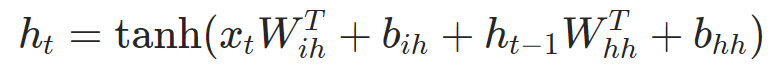

In [ ]:
import torch.nn as nn
import torch.nn.functional as F


class RNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(RNN, self).__init__()
        self.hidden_size = hidden_size

        ###########################################################################
        # TODO: Implement i2h, h2h
        ###########################################################################
        self.i2h = nn.Linear(input_size, hidden_size)
        self.h2h = nn.Linear(hidden_size, hidden_size)
        ###########################################################################
        #                             END OF YOUR CODE                            #
        ###########################################################################
        self.h2o = nn.Linear(hidden_size, output_size)
        self.softmax = nn.LogSoftmax(dim=1)

    def forward(self, input, hidden):
        ###########################################################################
        # TODO: Implement forward
        ###########################################################################
        hidden = F.tanh(self.i2h(input) + self.h2h(hidden))
        ###########################################################################
        #                             END OF YOUR CODE                            #
        ###########################################################################
        output = self.h2o(hidden)
        output = self.softmax(output)
        return output, hidden

    def initHidden(self):
        return torch.zeros(1, self.hidden_size)

n_hidden = 128
rnn = RNN(n_letters, n_hidden, n_categories)

##### Next Step

To run a step of this network we need to pass an input (in our case, the
Tensor for the current letter) and a previous hidden state (which we
initialize as zeros at first). We\'ll get back the output (probability
of each language) and a next hidden state (which we keep for the next
step).


In [ ]:
input = letterToTensor("A")
hidden = torch.zeros(1, n_hidden)

output, next_hidden = rnn(input, hidden)

For the sake of efficiency we don\'t want to be creating a new Tensor
for every step, so we will use `lineToTensor` instead of
`letterToTensor` and use slices. This could be further optimized by
precomputing batches of Tensors.


In [ ]:
input = lineToTensor("Albert")
hidden = torch.zeros(1, n_hidden)

output, next_hidden = rnn(input[0], hidden)
print(output)

tensor([[-2.8040, -3.0123, -2.9698, -2.9224, -2.9387, -2.9563, -2.9500, -3.0112,
         -2.8097, -2.9657, -2.7134, -2.7946, -2.9395, -2.8311, -2.8547, -2.9043,
         -2.8953, -2.8145]], grad_fn=<LogSoftmaxBackward0>)


As you can see the output is a `<1 x n_categories>` Tensor, where every
item is the likelihood of that category (higher is more likely).


Training
========

Preparing for Training
----------------------

Before going into training we should make a few helper functions. The
first is to interpret the output of the network, which we know to be a
likelihood of each category. We can use `Tensor.topk` to get the index
of the greatest value:


In [ ]:
def categoryFromOutput(output):
    top_n, top_i = output.topk(1)
    category_i = top_i[0].item()
    return all_categories[category_i], category_i


print(categoryFromOutput(output))

('Chinese', 10)


We will also want a quick way to get a training example (a name and its
language):


In [ ]:
import random


def randomChoice(l):
    return l[random.randint(0, len(l) - 1)]


def randomTrainingExample():
    category = randomChoice(all_categories)
    line = randomChoice(category_lines[category])
    category_tensor = torch.tensor([all_categories.index(category)], dtype=torch.long)
    line_tensor = lineToTensor(line)
    return category, line, category_tensor, line_tensor


for i in range(10):
    category, line, category_tensor, line_tensor = randomTrainingExample()
    print(f"category = {category} / line = {line} / category_tensor = {category_tensor}")

category = English / line = Dacey / category_tensor = tensor([6])
category = Chinese / line = Huan / category_tensor = tensor([10])
category = Japanese / line = Takagawa / category_tensor = tensor([1])
category = Korean / line = Yim / category_tensor = tensor([15])
category = Spanish / line = Fierro / category_tensor = tensor([4])
category = Scottish / line = Young / category_tensor = tensor([13])
category = Chinese / line = Cong / category_tensor = tensor([10])
category = Portuguese / line = Freitas / category_tensor = tensor([16])
category = Greek / line = Laganas / category_tensor = tensor([3])
category = Polish / line = Gwozdek / category_tensor = tensor([11])


Training the Network
====================

Now all it takes to train this network is show it a bunch of examples,
have it make guesses, and tell it if it\'s wrong.

For the loss function `nn.NLLLoss` is appropriate, since the last layer
of the RNN is `nn.LogSoftmax`.


In [ ]:
criterion = nn.NLLLoss()

Each loop of training will:

-   Create input and target tensors
-   Create a zeroed initial hidden state
-   Read each letter in and
    -   Keep hidden state for next letter
-   Compare final output to target
-   Back-propagate
-   Return the output and loss


In [ ]:
learning_rate = 5e-3  # If you set this too high, it might explode. If too low, it might not learn


def train(rnn, criterion, learning_rate, category_tensor, line_tensor):
    ###########################################################################
    # TODO: Implement training loop
    ###########################################################################
    hidden = rnn.initHidden()
    rnn.zero_grad()
    for i in range(line_tensor.size(0)):
      output, hidden = rnn(line_tensor[i], hidden)
    ###########################################################################
    #                             END OF YOUR CODE                            #
    ###########################################################################

    loss = criterion(output, category_tensor)
    loss.backward()

    # Add parameters' gradients to their values, multiplied by learning rate
    for p in rnn.parameters():
        p.data.add_(p.grad.data, alpha=-learning_rate)

    return output, loss.item()

Now we just have to run that with a bunch of examples. Since the `train`
function returns both the output and loss we can print its guesses and
also keep track of loss for plotting. Since there are 1000s of examples
we print only every `print_every` examples, and take an average of the
loss.


In [ ]:
import math
import time

n_iters = 100000
print_every = 5000
plot_every = 1000


# Keep track of losses for plotting
current_loss = 0
all_losses = []


def timeSince(since):
    now = int(time.time())
    s = now - since
    m = math.floor(s / 60)
    s -= m * 60
    return f"{m}m {s:02d}s"


start = int(time.time())

for iter in range(1, n_iters + 1):
    category, line, category_tensor, line_tensor = randomTrainingExample()
    output, loss = train(rnn, criterion, learning_rate, category_tensor, line_tensor)
    current_loss += loss

    # Print ``iter`` number, loss, name and guess
    if iter % print_every == 0:
        guess, guess_i = categoryFromOutput(output)
        correct = "✓" if guess == category else "✗ (%s)" % category
        print(f"{iter} {int(iter / n_iters * 100)}% ({timeSince(start)}) {loss:.4f} {line} / {guess} {correct}")

    # Add current loss avg to list of losses
    if iter % plot_every == 0:
        all_losses.append(current_loss / plot_every)
        current_loss = 0

5000 5% (0m 09s) 2.9326 Soler / German ✗ (Spanish)
10000 10% (0m 17s) 2.1051 Taylor / Arabic ✗ (Scottish)
15000 15% (0m 26s) 1.9909 Kenzel / German ✗ (Czech)
20000 20% (0m 35s) 0.5950 Yue / Chinese ✓
25000 25% (0m 43s) 0.2779 Bartolomei / Italian ✓
30000 30% (0m 53s) 3.3588 Estlick / Czech ✗ (English)
35000 35% (1m 02s) 0.5917 Jang / Korean ✓
40000 40% (1m 10s) 1.3500 Kogo / Korean ✗ (Japanese)
45000 45% (1m 19s) 0.7256 Harb / Arabic ✓
50000 50% (1m 28s) 0.5331 O'Connell / Irish ✓
55000 55% (1m 36s) 2.7257 Salomon / English ✗ (Polish)
60000 60% (1m 45s) 0.3628 Teunissen / Dutch ✓
65000 65% (1m 54s) 0.5067 Rhys / Irish ✓
70000 70% (2m 02s) 0.2034 Han / Chinese ✓
75000 75% (2m 11s) 0.0255 Ferreiro / Portuguese ✓
80000 80% (2m 20s) 0.3590 Black / Scottish ✓
85000 85% (2m 29s) 4.5466 Havinson / Scottish ✗ (Russian)
90000 90% (2m 38s) 0.0093 Corti / Italian ✓
95000 95% (2m 46s) 2.7438 Paulis / Greek ✗ (Dutch)
100000 100% (2m 56s) 1.2881 Aggelen / English ✗ (Dutch)


Plotting the Results
====================

Plotting the historical loss from `all_losses` shows the network
learning:


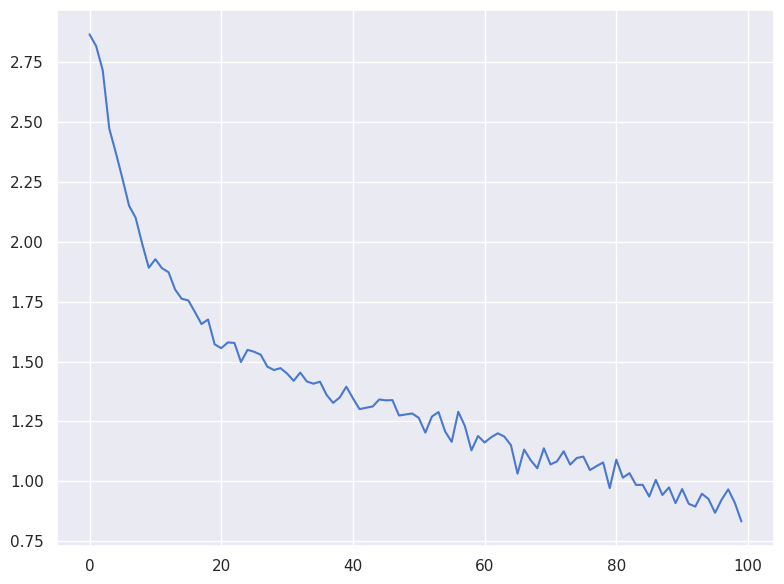

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.figure()
plt.plot(all_losses)
plt.show()

Evaluating the Results
======================

To see how well the network performs on different categories, we will
create a confusion matrix, indicating for every actual language (rows)
which language the network guesses (columns). To calculate the confusion
matrix a bunch of samples are run through the network with `evaluate()`,
which is the same as `train()` minus the backprop.


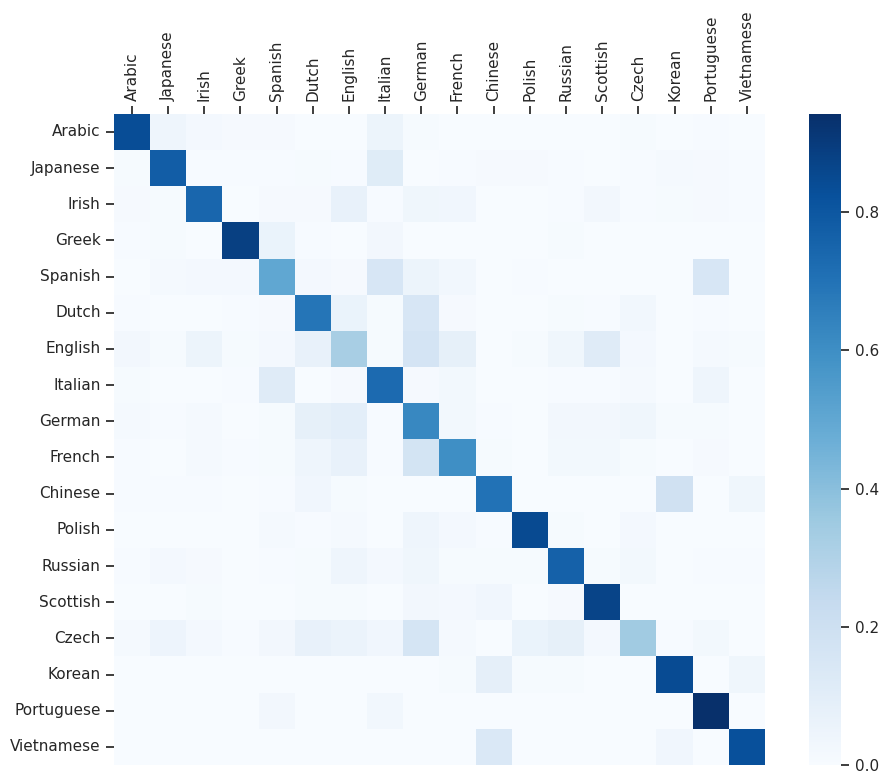

In [ ]:
# Keep track of correct guesses in a confusion matrix
confusion = torch.zeros(n_categories, n_categories)
n_confusion = 10000


# Just return an output given a line
def evaluate(line_tensor):
    hidden = rnn.initHidden()

    for i in range(line_tensor.size(0)):
        output, hidden = rnn(line_tensor[i], hidden)

    return output


# Go through a bunch of examples and record which are correctly guessed
for i in range(n_confusion):
    category, line, category_tensor, line_tensor = randomTrainingExample()
    output = evaluate(line_tensor)
    guess, guess_i = categoryFromOutput(output)
    category_i = all_categories.index(category)
    confusion[category_i][guess_i] += 1

# Normalize by dividing every row by its sum
for i in range(n_categories):
    confusion[i] = confusion[i] / confusion[i].sum()

# Plot confusion matrix
plt.figure(figsize=(10, 8))
ax = sns.heatmap(confusion, square=True, cmap="Blues")
ax.set_xticklabels(all_categories, rotation=90)
ax.set_yticklabels(all_categories, rotation=0)
ax.tick_params(axis="x", top=True, labelbottom=False, labeltop=True)
ax.tick_params(axis="y", left=True)
plt.show()

You can pick out bright spots off the main axis that show which
languages it guesses incorrectly, e.g. Chinese for Korean, and Spanish
for Italian. It seems to do very well with Greek, and very poorly with
English (perhaps because of overlap with other languages).


Running on User Input
=====================


In [ ]:
def predict(input_line, n_predictions=3):
    print("\n> %s" % input_line)

    with torch.no_grad():
        output = evaluate(lineToTensor(input_line))

        # Get top N categories
        topv, topi = output.topk(n_predictions, 1, True)
        predictions = []

        for i in range(n_predictions):
            value = topv[0, i].item()
            category_index = topi[0, i].item()
            print(f"({value:.2f}) {all_categories[category_index]}")
            predictions.append([value, all_categories[category_index]])

    return predictions


predict("Dovesky")
predict("Jackson")
predict("Satoshi")


> Dovesky
(-0.15) Russian
(-2.60) Czech
(-3.38) English

> Jackson
(-0.03) Scottish
(-4.26) English
(-4.75) Russian

> Satoshi
(-0.91) Japanese
(-1.39) Greek
(-2.38) Polish


[[-0.9082376956939697, 'Japanese'],
 [-1.3893167972564697, 'Greek'],
 [-2.3839235305786133, 'Polish']]